In [1]:
import ee
import os
import geemap
import pandas as pd
import geopandas as gpd
from pathlib import Path
import sys
import importlib
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import data_utils
import gee_utils
import plotting
import features_utils

importlib.reload(features_utils)
importlib.reload(data_utils)
importlib.reload(gee_utils)
importlib.reload(plotting)

<module 'plotting' from '/Users/bensutton/Projects/dissertation-code/src/plotting.py'>

In [2]:
PROJECT_ROOT = Path().resolve().parent

sys.path.append(str(PROJECT_ROOT / "src"))

from features_utils import add_indices, correlation_matrix
from plotting import set_pubr_theme, pubr_legend, pubr_fill

In [4]:
sample_fp = PROJECT_ROOT / "outputs" / "sample_points.csv"
indices_fp = PROJECT_ROOT / "configs" / "indices.json"


In [ ]:
# Screen out pixels with zero values as artifacts following atmospheric correction

samples = pd.read_csv(sample_fp, index_col= 0)

band_cols = ['AWEIp95', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8','B8A']

samples[band_cols] = samples[band_cols]/10000

samples.describe()

# mask_zero_values = (samples[band_cols] == 0).any(axis=1)

# # zero_value_points = samples.loc[mask_zero_values]

# # zero_value_fp = PROJECT_ROOT / "outputs/points_zero_values.csv"

# # zero_value_points.to_csv(zero_value_fp, index= False)

# print(f"Dropping {mask_zero_values.sum()} of {len(samples)} points")

# samples_clean = samples.loc[-mask_zero_values].reset_index(drop=True)

# samples_clean_fp = PROJECT_ROOT / "outputs" / "sample_points_clean.csv"

# samples_clean.to_csv(samples_clean_fp, index=False)

,AWEIp95,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,class_int,latitude,lc,longitude
count,16189.000000,16189.000000,16189.000000,16189.000000,16189.000000,16189.000000,16189.000000,16189.000000,16189.000000,16189.000000,16189.000000,16189.000000,16189.000000,16189.000000,16189.000000
mean,0.075079,0.095117,0.051393,0.035813,0.058411,0.040556,0.083181,0.179272,0.207877,0.218946,0.217369,2.324418,8.039585,0.497313,29.633848
std,0.175339,0.081470,0.053080,0.022819,0.030877,0.033807,0.049028,0.132375,0.158309,0.163589,0.169201,0.875572,16.965698,0.500008,74.290772
min,-0.625200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-25.778349,0.000000,-98.237739
25%,0.044000,0.018000,0.011700,0.023600,0.040400,0.023400,0.045400,0.044700,0.047000,0.046800,0.038500,2.000000,-0.368125,0.000000,-81.802595
50%,0.117200,0.085800,0.040000,0.033000,0.055200,0.033100,0.082100,0.182000,0.206300,0.225400,0.219100,3.000000,18.498168,0.000000,34.855446
75%,0.206800,0.148400,0.070300,0.043300,0.073100,0.045600,0.110800,0.274600,0.321500,0.337200,0.343000,3.000000,18.954431,1.000000,76.434896
max,0.936800,0.625300,0.609100,0.778400,0.731200,0.770400,0.493100,0.611900,0.718500,0.763200,0.748000,4.000000,29.553151,1.000000,110.470412


In [6]:

samples_w_indices = add_indices(samples, indices_file= indices_fp)

sample_indices_fp = PROJECT_ROOT / "outputs" / "sample_points_indices.csv"

samples_w_indices.to_csv(sample_indices_fp, index= False)

In [7]:
samples_w_indices.drop(['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8','B8A'], axis =1).describe()

,AWEIp95,class_int,latitude,lc,longitude,NDVI,NDWI,MNDWI,GNDVI,NDCI,...,NDBI,NDAVI,RR1,EVI,SAVI,DVI,OSAVI,AWEIsh,SABI,BSI
count,16189.000000,16189.000000,16189.000000,16189.000000,16189.000000,16148.000000,16145.000000,16189.000000,16145.000000,16149.000000,...,16189.000000,16139.000000,16154.000000,16189.000000,16189.000000,16189.000000,16189.000000,16189.000000,16149.000000,16189.000000
mean,0.075079,2.324418,8.039585,0.497313,29.633848,0.469578,-0.349131,-0.034741,0.349131,0.126246,...,-0.368244,0.474246,0.323251,0.000045,0.301903,0.160535,0.332899,-0.302103,1.964262,-0.280475
std,0.175339,0.875572,16.965698,0.500008,74.290772,0.453037,0.458071,0.441021,0.458071,0.179862,...,0.284738,0.480624,0.210381,0.000040,0.247500,0.150751,0.263368,0.313132,2.073710,0.223189
min,-0.625200,1.000000,-25.778349,0.000000,-98.237739,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-0.000046,-0.353427,-0.368100,-0.417480,-1.186825,-10.000000,-0.770482
25%,0.044000,2.000000,-0.368125,0.000000,-81.802595,0.149799,-0.683807,-0.415620,0.070632,0.024902,...,-0.544410,0.196399,0.162609,0.000003,0.033086,0.003300,0.052242,-0.545225,0.174901,-0.447283
50%,0.117200,3.000000,18.498168,0.000000,34.855446,0.687734,-0.557234,-0.150000,0.557234,0.188073,...,-0.447193,0.713198,0.368055,0.000043,0.339478,0.158400,0.411222,-0.323150,1.792969,-0.335678
75%,0.206800,3.000000,18.954431,1.000000,76.434896,0.807690,-0.070632,0.321364,0.683807,0.248950,...,-0.249191,0.817436,0.487444,0.000074,0.508174,0.270100,0.557257,0.007950,3.069159,-0.144595
max,0.936800,4.000000,29.553151,1.000000,110.470412,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,0.000167,0.812954,0.612600,0.775028,1.220200,72.800000,1.000000


In [ ]:
# Check undefined / NaN indices values
nan_samples = samples_w_indices[samples_w_indices.isna().any(axis=1)]

nan_samples = nan_samples.drop(['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8','B8A', 'class_label', 'label_id', 'latitude', 'longitude', 'lc', '.geo'], axis =1)

nan_samples.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69 entries, 6_1137_0 to 2_619_0
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AWEIp95    69 non-null     float64
 1   class_int  69 non-null     int64  
 2   location   69 non-null     object 
 3   obs_date   69 non-null     object 
 4   NDVI       28 non-null     float64
 5   NDWI       25 non-null     float64
 6   MNDWI      69 non-null     float64
 7   GNDVI      25 non-null     float64
 8   NDCI       29 non-null     float64
 9   NDMI       69 non-null     float64
 10  NDBI       69 non-null     float64
 11  NDAVI      19 non-null     float64
 12  RR1        34 non-null     float64
 13  EVI        69 non-null     float64
 14  SAVI       69 non-null     float64
 15  DVI        69 non-null     float64
 16  OSAVI      69 non-null     float64
 17  AWEIsh     69 non-null     float64
 18  SABI       29 non-null     float64
 19  BSI        69 non-null     float64
dtypes: fl

In [14]:
# Cleaned samples without NaN values for indices

samples_clean = samples_w_indices.dropna(subset= ['NDVI', 'NDWI', 'MNDWI',
       'GNDVI', 'NDCI', 'NDMI', 'NDBI', 'NDAVI', 'RR1', 'EVI', 'SAVI', 'DVI',
       'OSAVI', 'AWEIsh', 'SABI', 'BSI'])

print(len(samples_clean))
samples_clean_fp = PROJECT_ROOT / "outputs" / "sample_points_clean.csv"

samples_clean.to_csv(samples_clean_fp, index=False)

16120


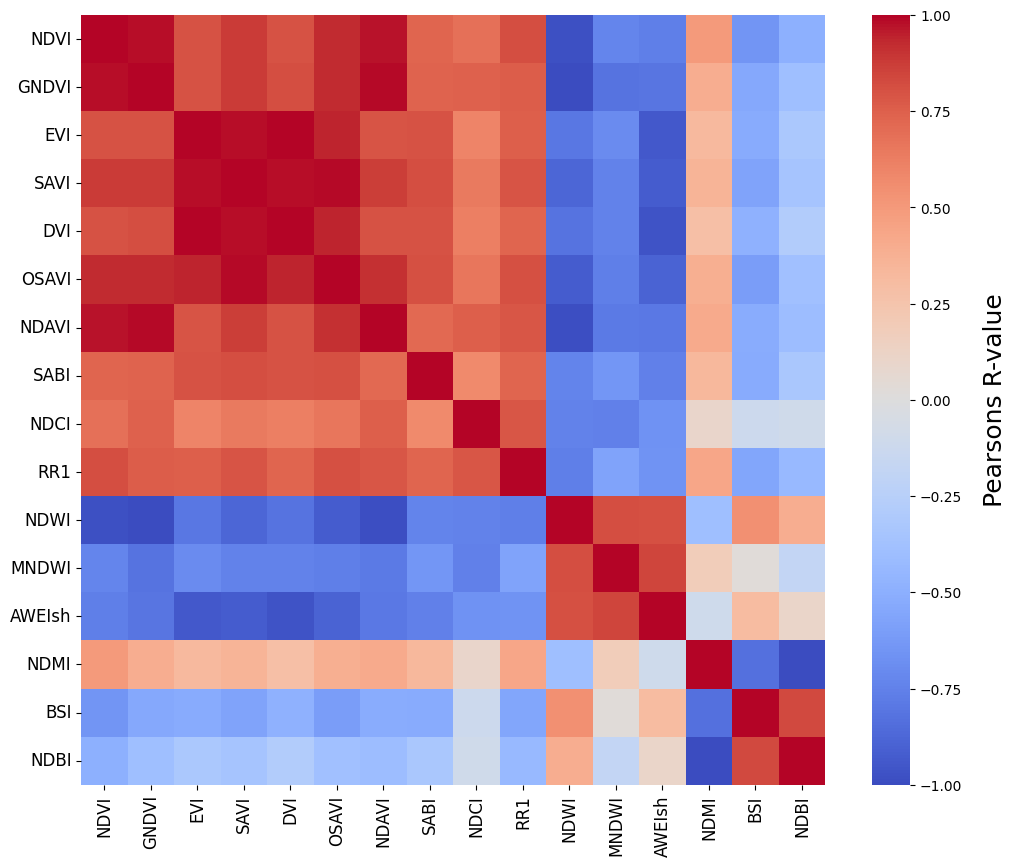

FileNotFoundError: [Errno 2] No such file or directory: '/Users/bensutton/Projects/outputs/corr_matrix.png'

In [ ]:
corr = correlation_matrix(samples_clean, columns= [
   'NDVI','GNDVI',  'EVI', 'SAVI',
       'DVI', 'OSAVI',"NDAVI","SABI", 'NDCI', "RR1",
       'NDWI','MNDWI','AWEIsh', 'NDMI', 'BSI','NDBI'])



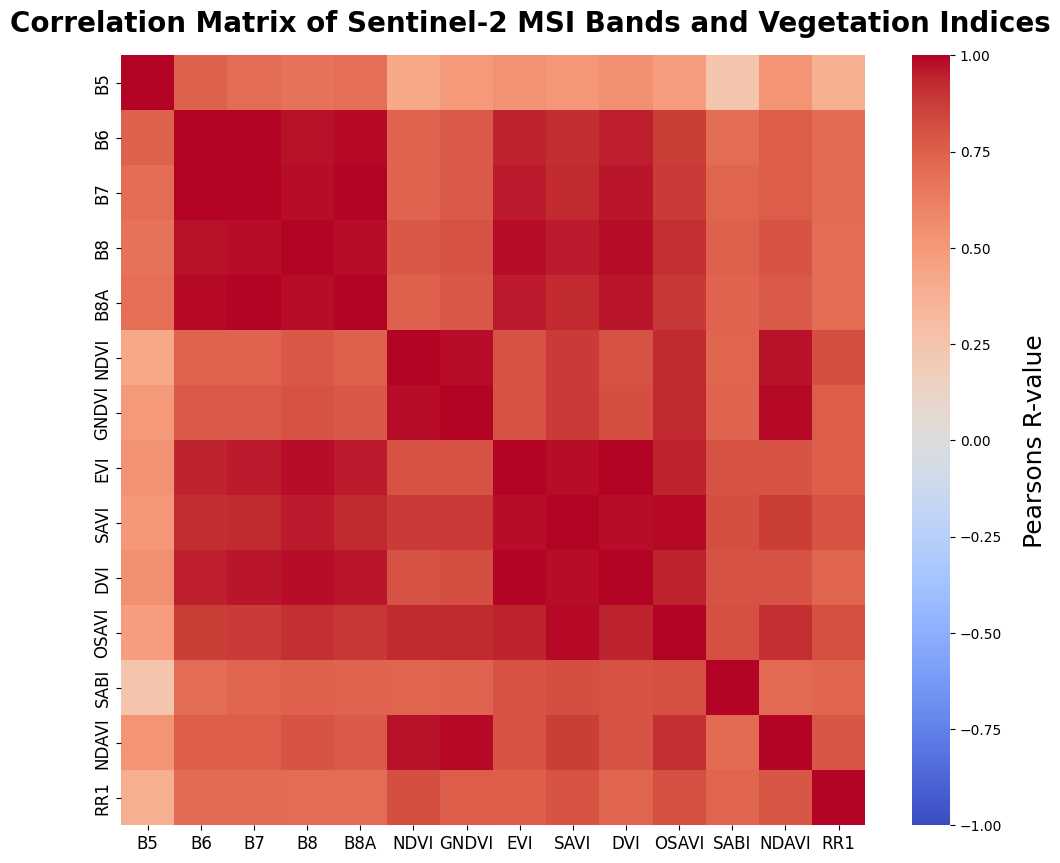

FileNotFoundError: [Errno 2] No such file or directory: '/Users/bensutton/Projects/outputs/corr_matrix.png'

In [10]:
veg_columns = ['B5', 'B6', 'B7', 'B8',
       'B8A','NDVI','GNDVI', 'EVI', 'SAVI','DVI','OSAVI',"SABI", "NDAVI", "RR1"]

veg_corr = correlation_matrix(samples_w_indices, columns= veg_columns, title = "Correlation Matrix of Sentinel-2 MSI Bands and Vegetation Indices")

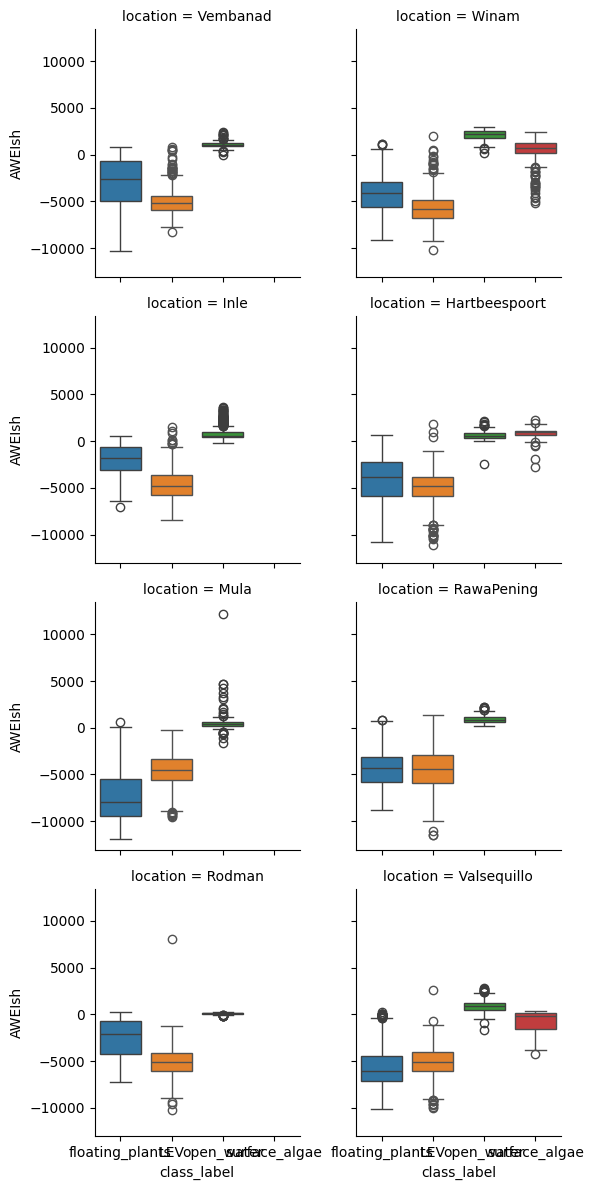

In [17]:
# Boxplots of bands and indices by class

g = sns.FacetGrid(samples_w_indices, col = "location", col_wrap = 2, hue = "class_label")
g.map_dataframe(sns.boxplot, y = "AWEIsh", x = "class_label"
                 )

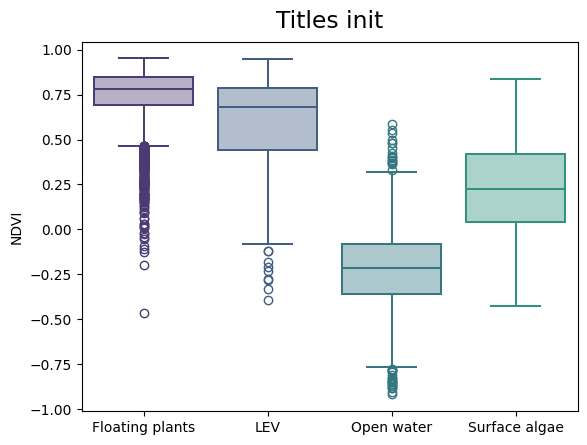

In [22]:

sns.set_palette("viridis") # Sets palette for seaborn globally

# Create a clean class labels column for display

labels = {
    "floating_plants": "Floating plants",
    "LEV": "LEV",
    "open_water": "Open water",
    "surface_algae": "Surface algae",
}

samples_w_indices["Class"] = samples_w_indices["class_label"].map(labels)
# or could map a new column using the above dict, this sureently wont change the xlabel names
fig, ax = plt.subplots()
set_pubr_theme(base_size=14)
sns.boxplot(data=samples_w_indices, 
            x="Class",
            y="NDVI",
            hue = "Class", 
            legend= False, 
            ax=ax)

pubr_legend(ax =ax, position= "top", relabel= labels)
pubr_fill(ax, alpha= 0.4, linewidth=None, legend = ax.get_legend())
ax.set_title("Titles init", pad = 10)
ax.set_xlabel("")
ax.set_ylabel("NDVI")
plt.show()

<Axes: title={'center': 'Vembanad'}, ylabel='NDVIre3'>

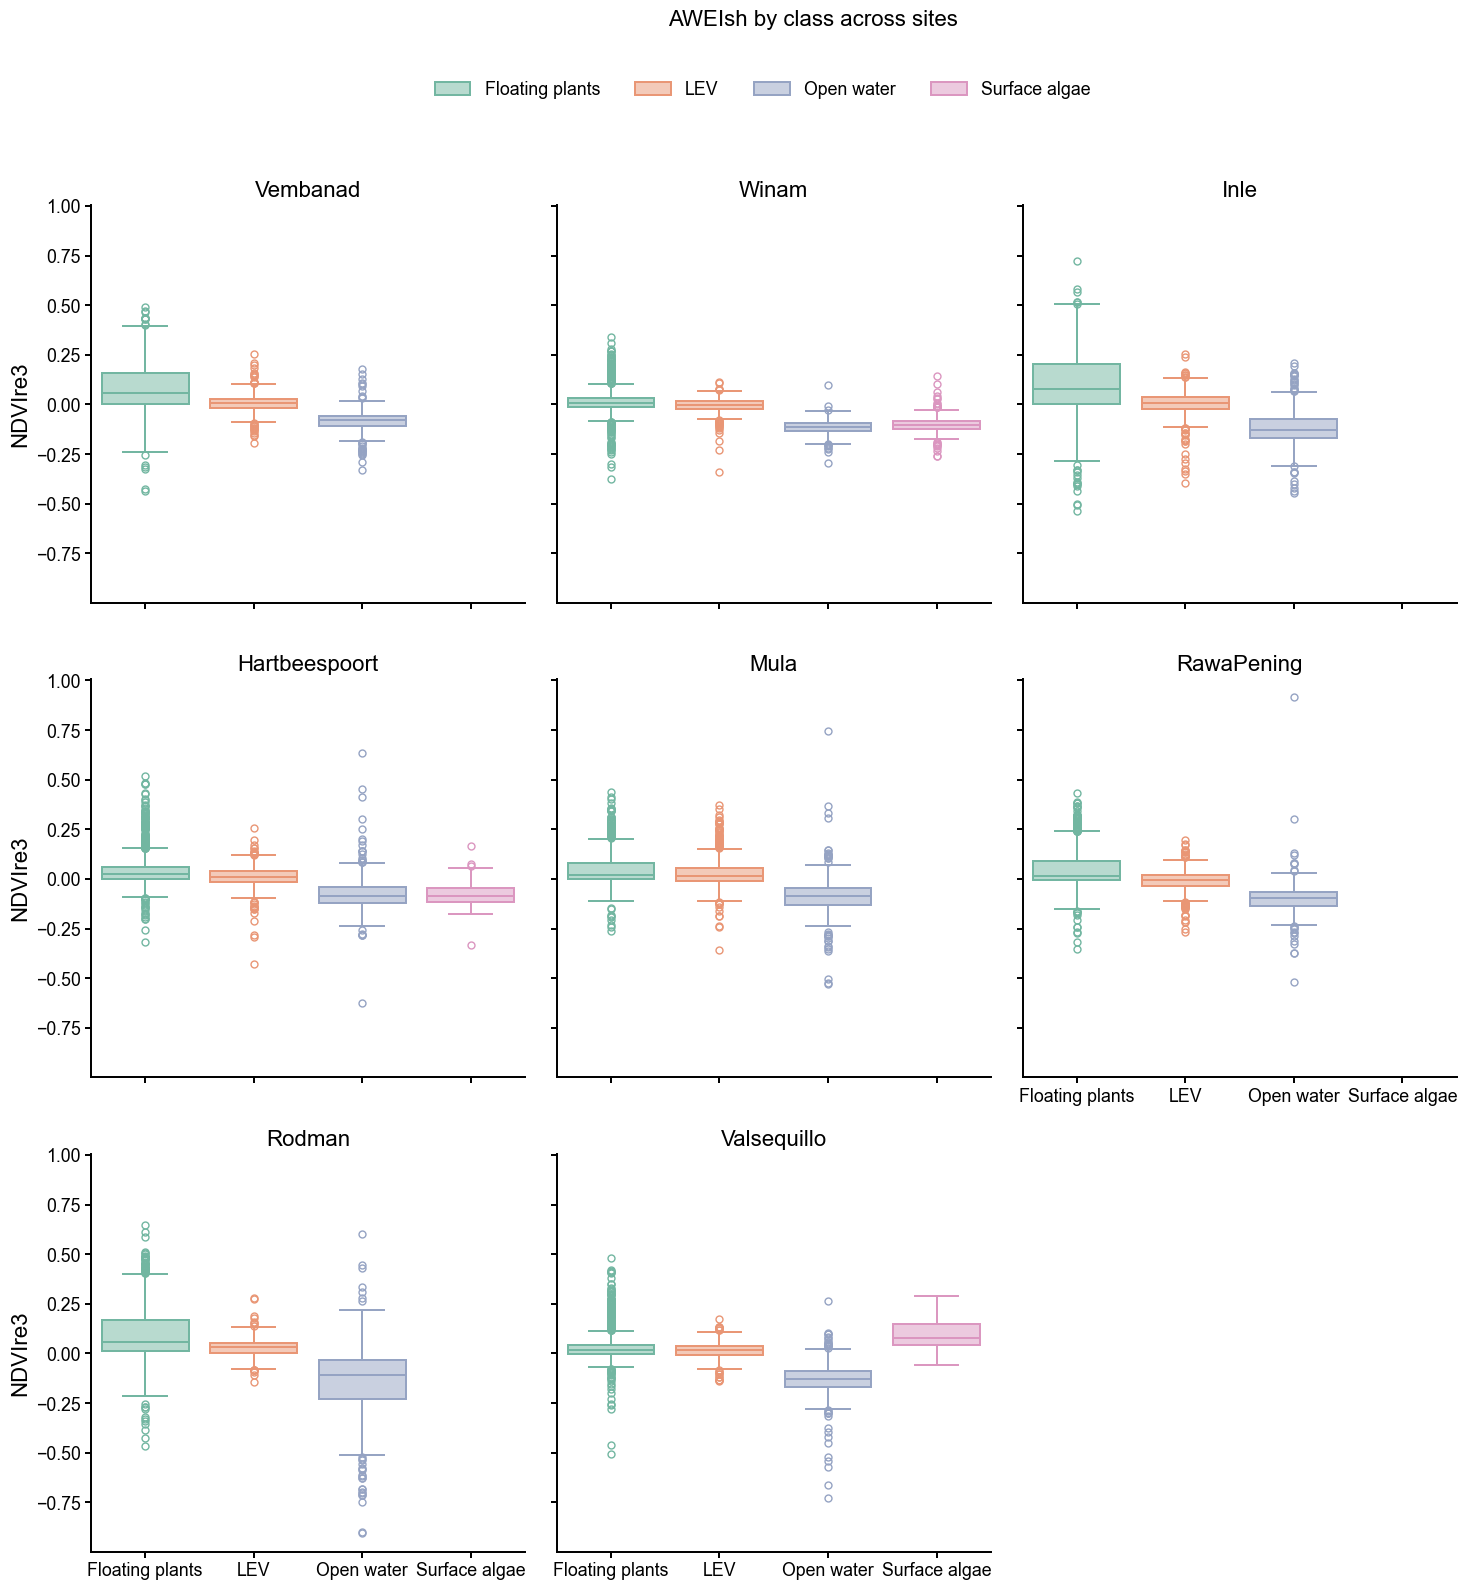

In [33]:
set_pubr_theme(base_size=16)

g = sns.catplot(
    data=samples_w_indices, kind="box",
    x="Class", y="NDVIre3", hue="Class",
    col="location",          # facet_wrap(~site)
    col_wrap=3,          # wrap after 3 columns
    palette="Set2",
    legend= True
)
g.set_titles("{col_name}")


for ax in g.axes.flat:          # pubr_fill is per-axes
    pubr_fill(ax)
    ax.set_xlabel("")

g.figure.suptitle("AWEIsh by class across sites", y=1.08, fontsize=16)
g.figure.subplots_adjust(top=0.95)        # make room so it isn't clipped

sns.move_legend(
    g, "lower center",
    bbox_to_anchor=(0.47, 1.01),   # just above the grid
    ncol=4,             # one row
    frameon=False,
    title=None,                  # drop the legend title if you want
)

pubr_fill(g.axes.flat[0], legend=g._legend)

<Axes: title={'center': 'NDVI'}>

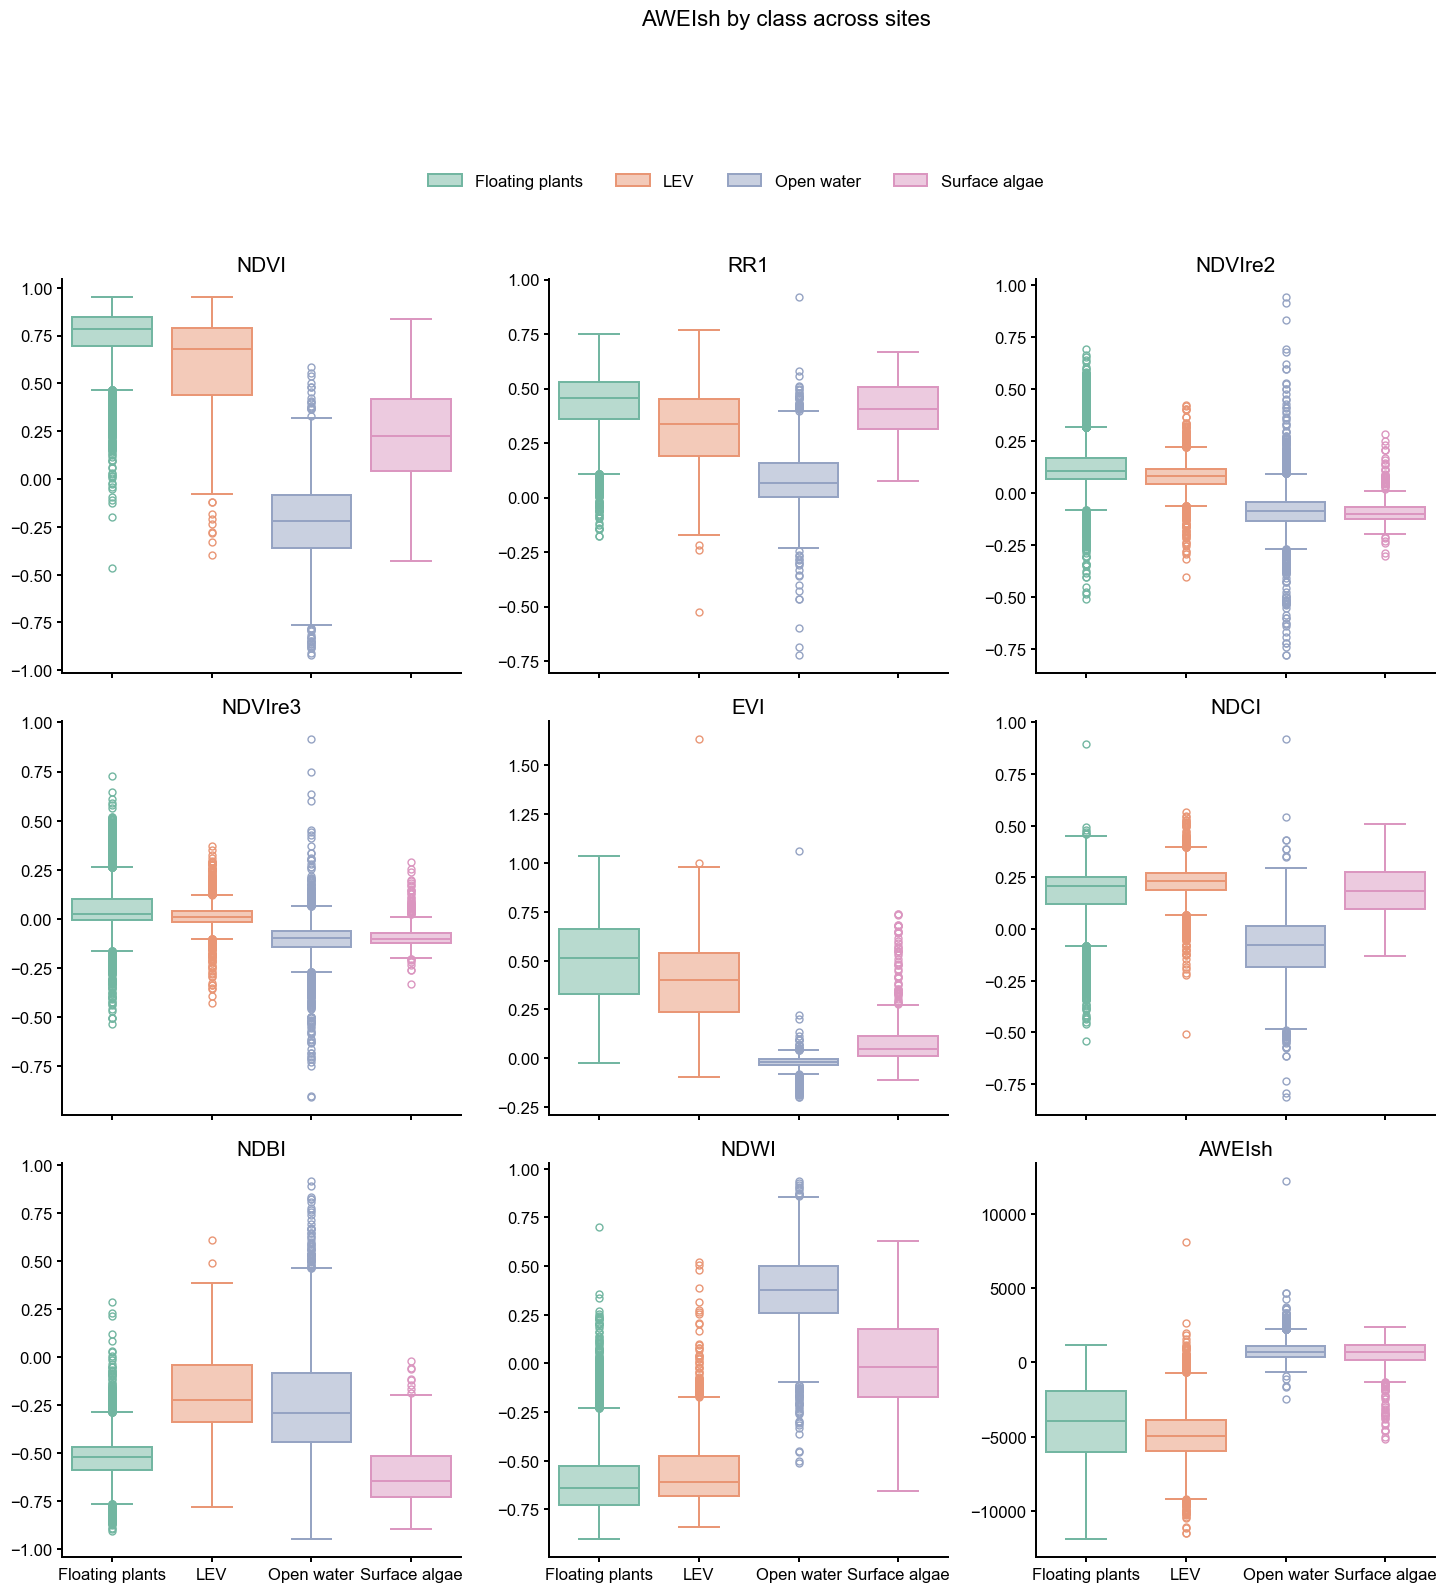

In [32]:
col_plot = ["NDVI", "RR1", "NDVIre2", "NDVIre3", "EVI", "NDCI",  "NDBI", "NDWI","AWEIsh" ]

long = samples_w_indices.melt(
    id_vars=["Class", "location"],     # columns to keep
    value_vars=col_plot,               # the indices to stack
    var_name="index",                  # new column holding "NDVI"/"AWEIsh"/"EVI"
    value_name="value",                # new column holding the numbers
)

set_pubr_theme(base_size=15)

g = sns.catplot(
    data=long, kind="box",
    x="Class", y="value",
    hue="Class",
    col="index",                       # facet_wrap(~index)
    col_order=col_plot,                # keep your list's order
    col_wrap=3,
    palette="Set2",
    sharey=False,                      # indices have different scales!
    legend=True,
)
g.set_titles("{col_name}")             # NDVI / AWEIsh / EVI

g.figure.suptitle("AWEIsh by class across sites", y=1.08, fontsize=16)
g.figure.subplots_adjust(top=0.9)        # make room so it isn't clipped

for ax in g.axes.flat:
    pubr_fill(ax)
    ax.set_xlabel("")
    ax.set_ylabel("")                  # otherwise every panel says "value"

sns.move_legend(
    g, "lower center",
    bbox_to_anchor=(0.47, 0.95),
    ncol=4,
    frameon=False,
    title=None,
)

pubr_fill(g.axes.flat[0], legend=g._legend)

In [210]:
test_patch_fp = "/Users/bensutton/Projects/dissertation-code/outputs/15px_patches/sampled_15_pixel_patches_for_Hartbeespoort.geojson"

with open(test_patch_fp,"r") as f:
    test_patch = json.load(f)

print(test_patch["features"][0]["properties"]["B8"])


[[5624, 5604, 5556, 5584, 5584, 5536, 5548, 5460, 5444, 5312, 5196, 4896, 4664, 4936, 5096], [5528, 5536, 5488, 5584, 5584, 5504, 5528, 5400, 5352, 5292, 5356, 5264, 5136, 4940, 4788], [5600, 5404, 5272, 5468, 5416, 5340, 5340, 5248, 5176, 5096, 5184, 5204, 5108, 4940, 4688], [5428, 5184, 5016, 5240, 5124, 5168, 5140, 5036, 5008, 4980, 5060, 5124, 4936, 4828, 4644], [5348, 5192, 5268, 5392, 5160, 5196, 5260, 5060, 4916, 4980, 5080, 5128, 5084, 4992, 4880], [5440, 5328, 5440, 5516, 5312, 5304, 5316, 5072, 4932, 4964, 5112, 5240, 5224, 5088, 5004], [5444, 5512, 5488, 5428, 5380, 5396, 5348, 5284, 5192, 5156, 5180, 5268, 5240, 5088, 5040], [5444, 5620, 5536, 5464, 5440, 5416, 5376, 5328, 5308, 5240, 5148, 5108, 5104, 5008, 5008], [5484, 5532, 5480, 5516, 5456, 5460, 5444, 5352, 5332, 5248, 5112, 5084, 5104, 5088, 5064], [5428, 5412, 5464, 5600, 5628, 5576, 5392, 5340, 5268, 5224, 5192, 5152, 5136, 5064, 4940], [5484, 5444, 5708, 5748, 5620, 5488, 5356, 5280, 5236, 5196, 5152, 5096, 4924, 

In [ ]:
## Index selection / feature importance
# Look af variance Inflation factor,
# Mutual Information classification per fold

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

def compute_vif(X: pd.DataFrame) -> pd.DataFrame:
    """Compute VIF for all features in X."""
    X_const = add_constant(X)  # statsmodels needs a constant term
    vif_data = pd.DataFrame({
        'feature': X.columns,
        'VIF': [
            variance_inflation_factor(X_const.values, i + 1)  # +1 to skip constant
            for i in range(X.shape[1])
        ]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)
    return vif_data

vif_df = compute_vif(X)
print(vif_df)

In [ ]:
cols = ['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'B8A', 'NDVI', 'NDWI', "NDVIre1", "NDVIre2","NDVIre3", "NDre1", "NDre2", "CIre", "MSRre",
       'MNDWI', 'GNDVI', 'NDCI', 'NDMI', 'NDBI', 'EVI', 'SAVI',
       'DVI', 'OSAVI', 'AWEIsh', 'BSI',"SABI", "NDAVI", "RR1"]



In [64]:
sample_fp = PROJECT_ROOT / "outputs" / "sample_points_indices.csv"
samples = pd.read_csv(sample_fp)

samples = samples.dropna(subset="lc")

pred_cols = ['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'B8A', 'NDVI', 'NDWI', "NDVIre1", "NDVIre2","NDVIre3", "NDre1", "NDre2", "CIre", "MSRre",
       'MNDWI', 'GNDVI', 'NDCI', 'NDMI', 'NDBI', 'EVI', 'SAVI',
       'DVI', 'OSAVI', 'AWEIsh', 'BSI', "SABI", "NDAVI", "RR1"]
metadata_cols = ["label_id","location","class_int", "class_label","obs_date"]


y = samples['lc'].values # values gives you numpy array
X = samples[pred_cols]#.values
metadata = samples[metadata_cols]
groups = samples['location'].values 

In [70]:
# Find rows with null columns
band_values = samples[['label_id','B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8',
       'B8A']]

band_values[samples.isna().any(axis=1)]



,label_id,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A
4564,IN0082_20250121,8,3,80,196,94,68,0,0,0,0
4565,IN0083_20250121,14,14,74,151,74,45,0,0,0,0
4566,IN0088_20250121,6,0,65,153,73,66,0,0,0,0
4761,IN0051_20230117,20,10,153,208,87,81,0,8,0,0
4767,IN0060_20230117,15,22,104,100,23,36,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
14593,VA0295_20210426,84,146,0,0,0,0,0,0,0,0
14594,VA0296_20210426,80,128,0,0,0,0,0,0,0,0
14595,VA0297_20210426,241,183,9,58,68,118,0,0,0,0
14597,VA0299_20210426,120,128,89,274,190,374,0,0,0,0


In [63]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16019 entries, 0 to 16018
Data columns (total 33 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   B11      16019 non-null  int64  
 1   B12      16019 non-null  int64  
 2   B2       16019 non-null  int64  
 3   B3       16019 non-null  int64  
 4   B4       16019 non-null  int64  
 5   B5       16019 non-null  int64  
 6   B6       16019 non-null  int64  
 7   B7       16019 non-null  int64  
 8   B8       16019 non-null  int64  
 9   B8A      16019 non-null  int64  
 10  NDVI     15978 non-null  float64
 11  NDWI     15975 non-null  float64
 12  NDVIre1  15967 non-null  float64
 13  NDVIre2  15889 non-null  float64
 14  NDVIre3  15902 non-null  float64
 15  NDre1    15968 non-null  float64
 16  NDre2    15974 non-null  float64
 17  CIre     15959 non-null  float64
 18  MSRre    15959 non-null  float64
 19  MNDWI    16019 non-null  float64
 20  GNDVI    15975 non-null  float64
 21  NDCI     159

In [58]:
from sklearn.feature_selection import mutual_info_regression
import numpy as np
import pandas as pd

regions = list(samples["location"].unique())

mi_per_fold = []

for test_region in regions:
    train_mask = samples['location'] != test_region
    X_train = X[train_mask]
    y_train = y[train_mask]
    
    mi = mutual_info_regression(X_train, y_train, random_state=42)
    mi_per_fold.append(mi)

# Average MI rank across folds
mi_matrix = np.array(mi_per_fold)  # shape: (n_folds, n_features)
mi_mean = pd.Series(mi_matrix.mean(axis=0), index=X.columns)
mi_std  = pd.Series(mi_matrix.std(axis=0),  index=X.columns)

# Features with consistently high MI across folds are the robust choices

ValueError: Input X contains NaN.